Importing Modules

In [99]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

Importing dataset

In [86]:
df = pd.read_csv("powerplant_data.csv")
df.shape

(9568, 5)

In [87]:
X = df.drop("PE", axis=1)
y = df["PE"]

Test-train split

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scaling

In [89]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Tensor Formation

In [90]:
torch.manual_seed(42)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

Dataset & Dataloader

In [91]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [92]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

Deep Learning

In [93]:
#Define our ANN model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            #2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            #3rd output Layer
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)


In [94]:
model = ANN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [95]:
#Train the model
epochs = 100
train_loss = []
val_loss = []
best_val_loss = float("inf")

for epoch in range(epochs):

    model.train() #mode
    
    running_loss = 0.0
    running_val_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb) #predicted outputs
        loss = criterion(outputs, yb) #calculating loss function
        loss.backward() #backward propagation...compute gradients
        optimizer.step() #updating weight and bias
        running_loss += loss.item() #tensor=>py float

    epoch_train_loss = running_loss/len(train_loader)
    train_loss.append(epoch_train_loss)

    model.eval()

    with torch.no_grad():
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()
        
    epoch_val_loss = running_val_loss/len(test_loader)
    val_loss.append(epoch_val_loss)
    
    if(epoch_val_loss<best_val_loss):
        best_val_loss = running_val_loss
        torch.save(model.state_dict(), "best_model.pt")
        
    print(f"epoch {epoch+1}/{epochs}==> training loss= {epoch_train_loss} validation loss= {epoch_val_loss}")



epoch 1/100==> training loss= 205893.85826822917 validation loss= 204270.88645833332
epoch 2/100==> training loss= 199899.062890625 validation loss= 192774.4265625
epoch 3/100==> training loss= 180244.65546875 validation loss= 164785.51510416667
epoch 4/100==> training loss= 144655.23977864583 validation loss= 123172.12721354167
epoch 5/100==> training loss= 101024.17794596354 validation loss= 80024.47389322917
epoch 6/100==> training loss= 62692.35336914063 validation loss= 48407.662109375
epoch 7/100==> training loss= 38906.730297851565 validation loss= 31705.681770833333
epoch 8/100==> training loss= 27443.56278076172 validation loss= 24050.300325520835
epoch 9/100==> training loss= 21995.214265950523 validation loss= 20005.51534830729
epoch 10/100==> training loss= 18664.12381998698 validation loss= 17093.157470703125
epoch 11/100==> training loss= 15942.836088053386 validation loss= 14476.166731770832
epoch 12/100==> training loss= 13339.305674235025 validation loss= 11927.2402994

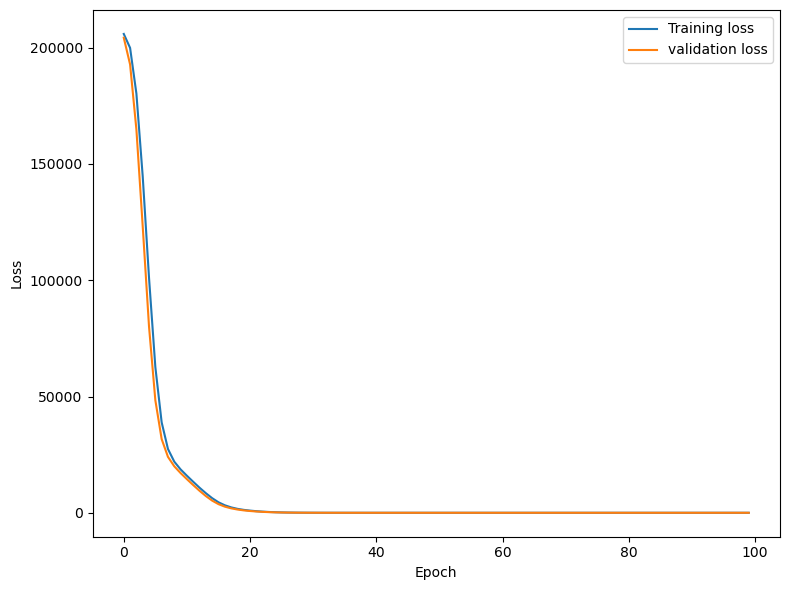

In [96]:
plt.figure(figsize=(8,6))
plt.plot(train_loss, label="Training loss")
plt.plot(val_loss, label="validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

In [97]:
model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>

In [98]:
model.eval()

with torch.no_grad():
    output_train = model(X_train_tensor)
    train_loss = criterion(output_train, y_train_tensor)
    output_test = model(X_test_tensor)
    test_loss = criterion(output_test, y_test_tensor)

print(f"MSE for training data = {train_loss}\nMSE for testing data = {test_loss}")

MSE for training data = 20.84662437438965
MSE for testing data = 19.237096786499023


In [102]:
r2_train = r2_score(y_train, output_train)
r2_test = r2_score(y_test, output_test)
print(f"Train r2 = {r2_train}\nTest r2 = {r2_test}")

Train r2 = 0.9287348380988686
Test r2 = 0.9327713088503786


In [115]:
eval = pd.DataFrame({"Actual":y_test.values, "Predicted":output_test.numpy().flatten()})
eval

,Actual,Predicted
0,433.27,435.601532
1,438.16,437.153687
2,458.42,461.565674
3,480.82,476.498352
4,441.41,435.474243
...,...,...
1909,456.70,451.740540
1910,438.04,431.927704
1911,467.80,467.862091
1912,437.14,431.307220


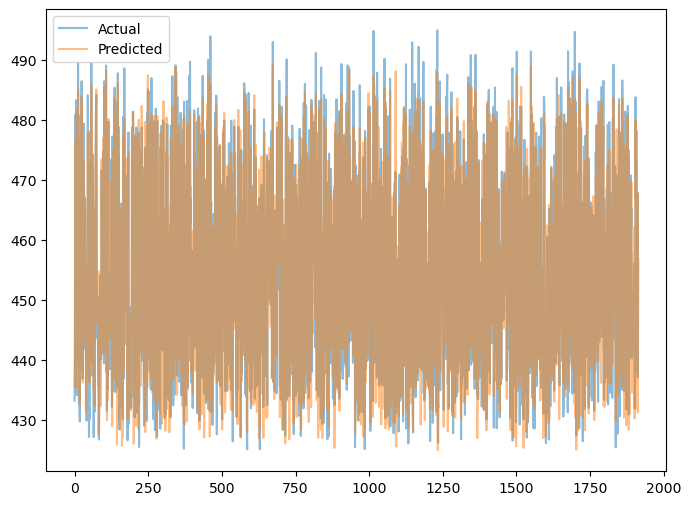

In [122]:
plt.figure(figsize=(8,6))
plt.plot(eval["Actual"], label="Actual", alpha=0.5)
plt.plot(eval["Predicted"], label="Predicted", alpha=0.5)
plt.legend()